# Tutorial for DataSource class

In [1]:
import os
os.chdir('..vdapseisutils/')
os.getcwd()

'/Users/jwellik/PYTHON/vdapseisutils'

In [2]:
from waveformutils.datasource import DataSource
from waveformutils.plotting.swarmmpl import swarmw

## Option 1: Open data from FDSN waveserver

DataSource: FDSN Client IRIS
>>> waveformutils.datasource[__init__].get_waveforms_from_client()
- Loading UW.SEP..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
Creating empty trace.
- Loading UW.YEL..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.HSR..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.SHW..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.EDM..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.STD..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.JUN..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z
- Loading UW.SOS..EHZ
  - Downloading   : 2004-10-15T00:00:00.000000Z to 2004-10-15T00:30:00.000000Z

  - All the data are downloaded
  - Sorting stream by NSLC
8 Trace(s) in 

<AxesSubplot:ylabel='UW.SOS..EHZ'>

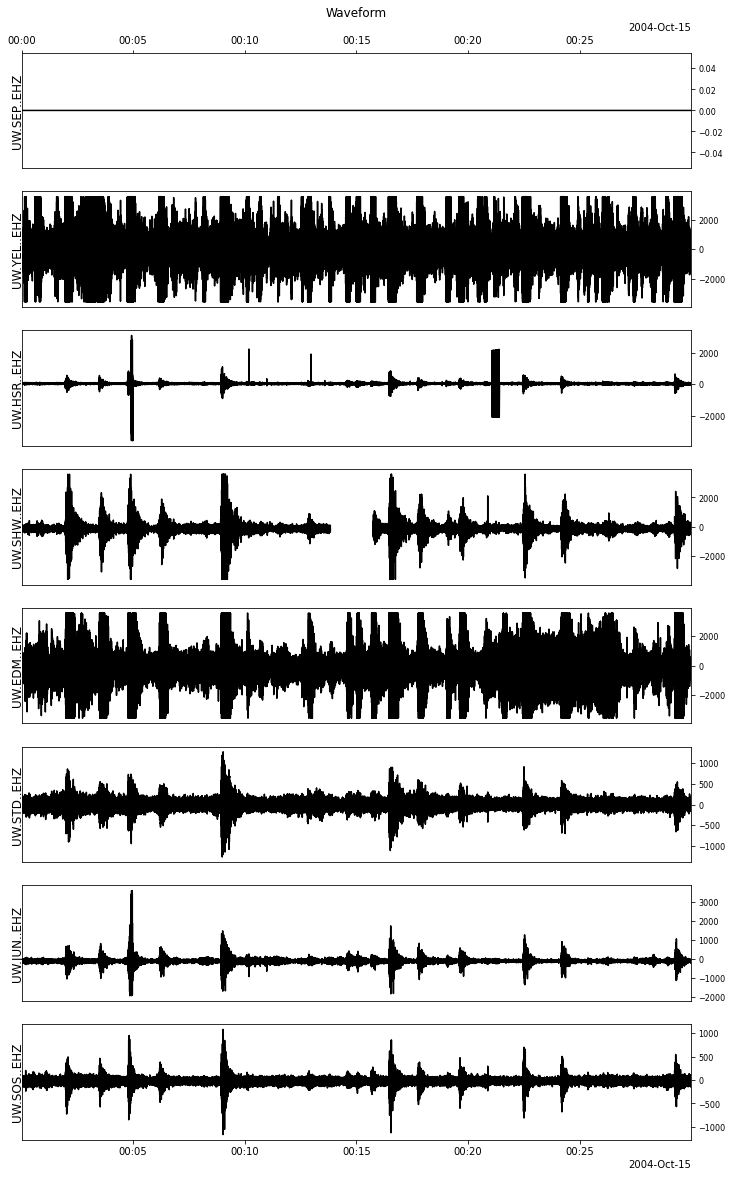

In [3]:
nslc_list = [ 'UW.SEP..EHZ',
              'UW.YEL..EHZ',
              'UW.HSR..EHZ',
              'UW.SHW..EHZ',
              'UW.EDM..EHZ',
              'UW.STD..EHZ',
              'UW.JUN..EHZ',
              'UW.SOS..EHZ',
       ]
ds = DataSource('fdsn', 'IRIS')
st = ds.getWaveforms(nslc_list,'2004/10/15 00:00:00', '2004/10/15 00:30:00', create_empty_trace=True, verbose=True)
print(st)
swarmw(st)

## Archive Data

* Does *NOT* store empty data

In [4]:
ds = DataSource('fdsn', 'IRIS')
ds.archive(nslc_list, '2004/10/15 00:00:00', '2004/10/15 01:00:00', basedir='/Users/jwellik/vdapseisutils/data/cont', verbose=False)

DataSource: FDSN Client IRIS
Archiving data from : FDSN Client IRIS
Archive destination : </Users/jwellik/vdapseisutils/data/cont>YEAR/NET/STA/CHAN.TYPE/NET.STA.LOC.CHAN.TYPE.YEAR.JDAY.EXTENSION
- Accessing UW.SEP..EHZ
 - Processing    : 2004-10-15T00:00:00.000000Z to 2004-10-15T01:00:00.000000Z
 - No Streams returned : UW.SEP..EHZ (2004-10-15T00:00:00.000000Z to 2004-10-15T01:00:00.000000Z)
- Accessing UW.YEL..EHZ
 - Processing    : 2004-10-15T00:00:00.000000Z to 2004-10-15T01:00:00.000000Z
   - Retrieved   : UW.YEL..EHZ | 2004-10-15T00:00:00.009900Z to 2004-10-15T00:59:59.999900Z | 100.0 Hz, 360000 samples
 - Archived! >>> /Users/jwellik/vdapseisutils/data/cont/2004/UW/YEL/EHZ.D/UW.YEL..EHZ.D.2004.289.mseed
- Accessing UW.HSR..EHZ
 - Processing    : 2004-10-15T00:00:00.000000Z to 2004-10-15T01:00:00.000000Z
   - Retrieved   : UW.HSR..EHZ | 2004-10-15T00:00:00.009900Z to 2004-10-15T00:59:59.999900Z | 100.0 Hz, 360000 samples
 - Archived! >>> /Users/jwellik/vdapseisutils/data/cont/2004

## Option 2: Data from File Structure

DataSource: /Users/jwellik/vdapseisutils/data
>>> waveforms.datasource[__init__].get_waveforms_from_files()
['/Users/jwellik/vdapseisutils/data/cont/2004/UW/SHW/EHZ.D/UW.SHW..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/YEL/EHZ.D/UW.YEL..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/STD/EHZ.D/UW.STD..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/EDM/EHZ.D/UW.EDM..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/SOS/EHZ.D/UW.SOS..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/HSR/EHZ.D/UW.HSR..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/JUN/EHZ.D/UW.JUN..EHZ.D.2004.289.mseed']
['/Users/jwellik/vdapseisutils/data/cont/2004/UW/YEL/EHZ.D/UW.YEL..EHZ.D.2004.289.mseed', '/Users/jwellik/vdapseisutils/data/cont/2004/UW/HSR/EHZ.D/UW.HSR..EHZ.D.2004.289.mseed']


<AxesSubplot:ylabel='UW.HSR..EHZ'>

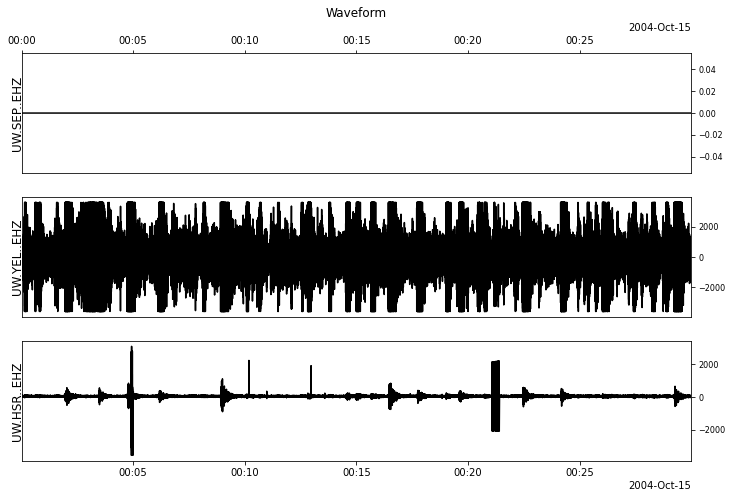

In [5]:
ds = DataSource('files', '/Users/jwellik/vdapseisutils/data', filepattern='*mseed')
st = ds.getWaveforms(['UW.SEP..EHZ', 'UW.YEL..EHZ', 'UW.HSR..EHZ'], '2004/10/15 00:00:00', '2004/10/15 00:30:00', create_empty_trace=True)
swarmw(st)

## Option 3: Data from some other Waveserver

DataSource: EW Client vdap.org:16024
>>> waveformutils.datasource[__init__].get_waveforms_from_client()
- Loading VG.TMKS.00.EHZ
  - Downloading   : 2017-11-22T00:00:00.000000Z to 2017-11-22T00:30:00.000000Z
- Loading VG.PSAG.00.EHZ
  - Downloading   : 2017-11-22T00:00:00.000000Z to 2017-11-22T00:30:00.000000Z
- Loading VG.ABNG.00.SHZ
  - Downloading   : 2017-11-22T00:00:00.000000Z to 2017-11-22T00:30:00.000000Z

  - All the data are downloaded
  - Sorting stream by NSLC
3 Trace(s) in Stream:
VG.TMKS.00.EHZ | 2017-11-22T00:00:00.000001Z - 2017-11-22T00:29:59.990001Z | 100.0 Hz, 180000 samples
VG.PSAG.00.EHZ | 2017-11-22T00:00:00.000001Z - 2017-11-22T00:29:59.990001Z | 100.0 Hz, 180000 samples
VG.ABNG.00.SHZ | 2017-11-22T00:00:00.005000Z - 2017-11-22T00:29:59.985000Z | 50.0 Hz, 90000 samples


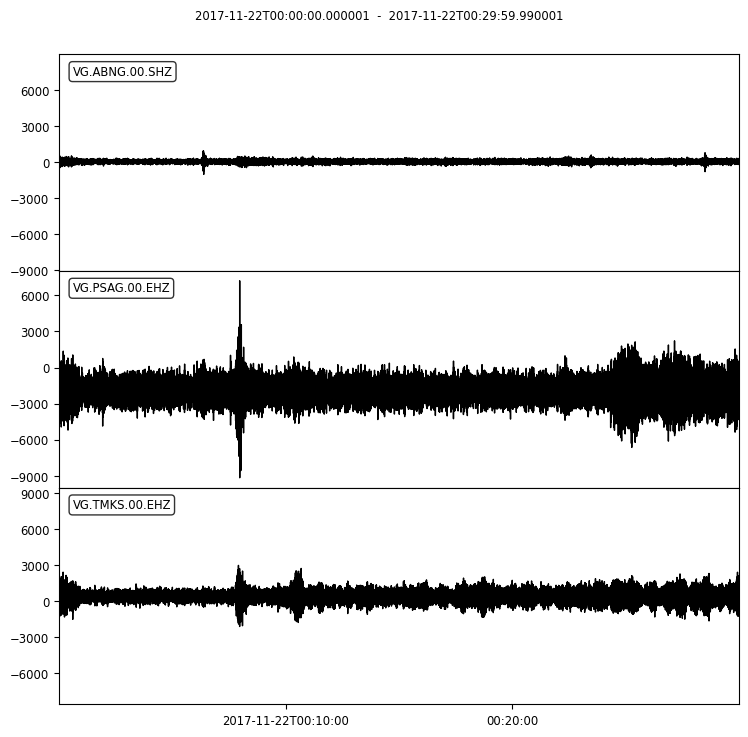

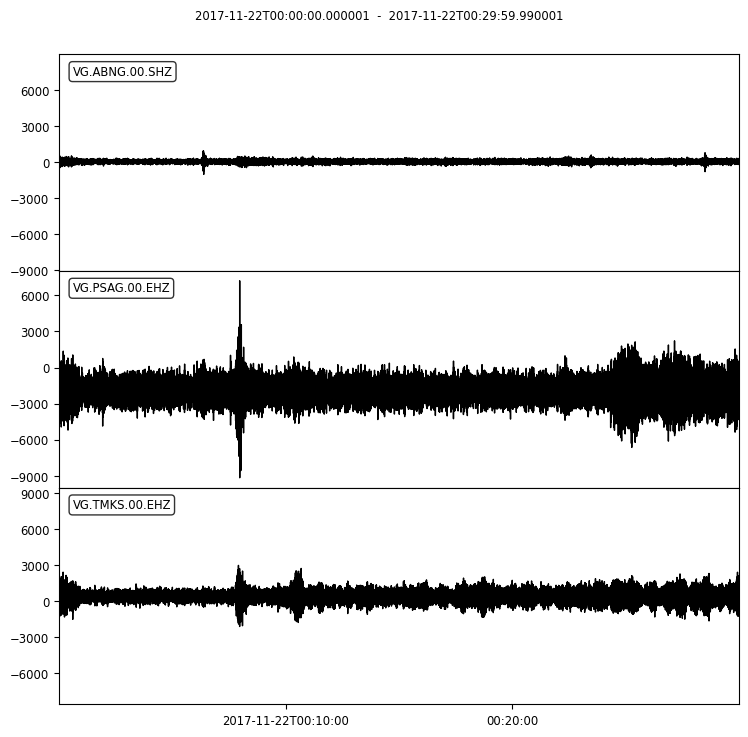

In [6]:
ds = DataSource('ew', 'vdap.org:16024')
st = ds.getWaveforms(['VG.TMKS.00.EHZ', 'VG.PSAG.00.EHZ', 'VG.ABNG.00.SHZ'], '2017/11/22 00:00:00', '2017/11/22 00:30:00', verbose=True)
print(st)
st.plot()